In [1]:
!pip install cell-gears


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# 89,357 cells X 5,045 genes — single-cell RNA-seq from cells subjected to CRISPR-based perturbations (
# this dataset uses CRISPRa to activate combinations of transcription factors and other genes), plus unperturbed controls.

# Rows = individual cells (89,357 of them)
# Columns = genes (5,045 of them).
# Each cell in the spreadsheet = how much that gene was expressed in that cell.

import os
import scanpy as sc
from gears import PertData

data_path = "./data"
if not os.path.exists(data_path):
    os.makedirs(data_path)

pert_data = PertData(data_path)
pert_data.load(data_name="norman")   
adata = pert_data.adata

print(adata)

/Users/bhumikamakwana/.pyenv/versions/3.11.4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/bhumikamakwana/.pyenv/versions/3.11.4/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
['RHOXF2BB+ctrl' 'LYL1+IER5L' 'ctrl+IER5L' 'KIAA1804+ctrl' 'IER5L+ctrl'
 'RHOXF2BB+ZBTB25' 'RHOXF2BB+SET']
Local copy of pyg dataset is detected. Loading...
Done!


View of AnnData object with n_obs × n_vars = 89357 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


obs: Information about each ROW (each cell) ["obs" = observations = cells.] For every cell, we know:
- condition: which gene(s) were switched on in that cell (or "ctrl" if nothing was switched — a baseline/untouched cell)
- cell_type - what kind of cell it is (here, they're all one type, a cell line called K562)
- dose_val - how strong the perturbation was
- control - simple yes/no: is this an untouched baseline cell? [control = True → the cell was NOT perturbed. It's a baseline/untouched cell/ control = False → the cell WAS perturbed (some gene or genes were switched on).]
- condition_name - just a nicely formatted version of condition

var - information about each COLUMN (each gene), "var" = variables = genes.[gene_name — the human-readable name of the gene (like "FOXA1")]

In [3]:
print(adata.obs[['condition', 'control']].iloc[0])

condition    TSC22D1+ctrl
control                 0
Name: AAACCTGAGGCATGTG-1, dtype: object


TSC22D1+ctrl	its value - this cell had gene TSC22D1 switched on

its value - 0 means False, so this cell is not a control cell (it's confirming what condition already told you)


**This cell had the gene TSC22D1 deliberately activated (a perturbation), and is not part of the control/baseline group.**

In [4]:
print(adata.obs[['condition', 'control']].iloc[:5])

                        condition  control
cell_barcode                              
AAACCTGAGGCATGTG-1   TSC22D1+ctrl        0
AAACCTGAGGCCCTTG-1    KLF1+MAP2K6        0
AAACCTGCACGAAGCA-1           ctrl        1
AAACCTGCAGACGTAG-1  CEBPE+RUNX1T1        0
AAACCTGCAGCCTTGG-1     MAML2+ctrl        0


In [5]:
print(adata.obs[:].iloc[:5])

                        condition cell_type dose_val  control  \
cell_barcode                                                    
AAACCTGAGGCATGTG-1   TSC22D1+ctrl      A549      1+1        0   
AAACCTGAGGCCCTTG-1    KLF1+MAP2K6      A549      1+1        0   
AAACCTGCACGAAGCA-1           ctrl      A549        1        1   
AAACCTGCAGACGTAG-1  CEBPE+RUNX1T1      A549      1+1        0   
AAACCTGCAGCCTTGG-1     MAML2+ctrl      A549      1+1        0   

                            condition_name  
cell_barcode                                
AAACCTGAGGCATGTG-1   A549_TSC22D1+ctrl_1+1  
AAACCTGAGGCCCTTG-1    A549_KLF1+MAP2K6_1+1  
AAACCTGCACGAAGCA-1             A549_ctrl_1  
AAACCTGCAGACGTAG-1  A549_CEBPE+RUNX1T1_1+1  
AAACCTGCAGCCTTGG-1     A549_MAML2+ctrl_1+1  


In [6]:
# Perturbed cells: TSC22D1 was activated
perturbed = adata[adata.obs['condition'] == 'TSC22D1+ctrl']

# Control cells: nothing activated (baseline)
control = adata[adata.obs['condition'] == 'ctrl']

print("Perturbed cells:", perturbed.shape[0])
print("Control cells:", control.shape[0])

Perturbed cells: 376
Control cells: 7353


**For TSC22D1 itself, is the average expression higher in perturbed cells?** You're expecting perturbed > control, since TSC22D1 was artificially switched on.

In [7]:
gene_idx = adata.var['gene_name'] == 'TSC22D1'

perturbed_mean = perturbed[:, gene_idx].X.mean()
control_mean = control[:, gene_idx].X.mean()

print("TSC22D1 mean expression — perturbed:", perturbed_mean)
print("TSC22D1 mean expression — control:", control_mean)

TSC22D1 mean expression — perturbed: 1.2588947
TSC22D1 mean expression — control: 0.30518633


ENSG00000102804


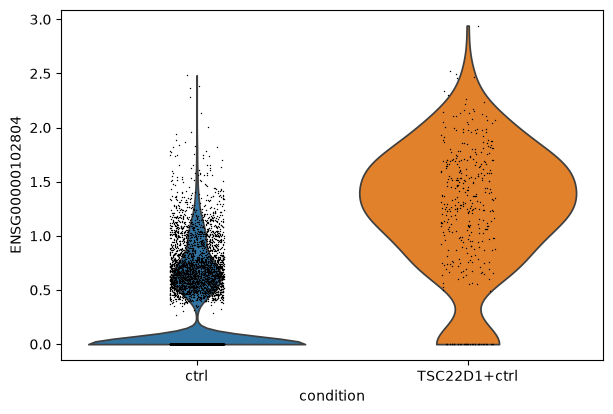

In [9]:
# Get the Ensembl ID for TSC22D1
# 1. Recreate the subset (control + TSC22D1 perturbed cells)
subset = adata[adata.obs['condition'].isin(['ctrl', 'TSC22D1+ctrl'])]

# 2. Get the Ensembl ID for TSC22D1
ensembl_id = adata.var.index[adata.var['gene_name'] == 'TSC22D1'][0]
print(ensembl_id)

# Use that ID in the plot
sc.pl.violin(subset, [ensembl_id], groupby='condition')

The black dots: individual cells, jittered sideways so they don't all overlap — each dot is one cell's expression value for TSC22D1.

- Blue (control): most cells cluster low, around 0.5–1.0, with a long thin tail up to ~2.5. This is TSC22D1's normal, baseline expression level.

- Orange (perturbed): the whole distribution has shifted upward — most cells now sit around 1.5–2.0, with the bulk of the violin noticeably "fatter" higher up, and some cells reaching almost 3.0.


TSC22D1 → the gene that was artificially activated (via CRISPR) in these cells
+ctrl → shorthand meaning "and nothing else was added." It's not a second gene — it's just the dataset's formatting convention for single-gene perturbations.

In [13]:
keys = list(adata.uns['rank_genes_groups_cov_all'].keys())
print(keys[:10])

['A549_AHR+FEV_1+1', 'A549_AHR+KLF1_1+1', 'A549_AHR+ctrl_1+1', 'A549_ARID1A+ctrl_1+1', 'A549_ARRDC3+ctrl_1+1', 'A549_ATL1+ctrl_1+1', 'A549_BAK1+ctrl_1+1', 'A549_BCL2L11+BAK1_1+1', 'A549_BCL2L11+TGFBR2_1+1', 'A549_BCL2L11+ctrl_1+1']


**Consider multiple gene pertuebations for plotting**

The core idea, restated
> For each perturbation (switching on gene X), you're asking:
>> "Compared to doing nothing, how does switching on gene X change the expression of every other measured gene?"

You're not just checking if gene X itself went up — you're checking the ripple effect across the rest of the cell's gene expression. Genes don't work in isolation; switching one on can activate or suppress dozens/hundreds of downstream genes, because genes regulate each other in networks (X turns on Y, Y suppresses Z, etc.).

In [14]:
perturbations = ['TSC22D1+ctrl', 'FOXA1+ctrl', 'FOXL2+ctrl']   # adjust to real condition names in your data
print(adata.obs['condition'].value_counts().loc[perturbations])

condition
TSC22D1+ctrl    376
FOXA1+ctrl      426
FOXL2+ctrl      303
Name: count, dtype: int64


In [15]:
subset = adata[adata.obs['condition'].isin(['ctrl'] + perturbations)].copy()

This is the best way to see all perturbations vs baseline at once, visually: through umap - dimensionality reduction technique

Principal Component Analysis (PCA) is a fast, linear method that preserves global variance, while Uniform Manifold Approximation and Projection (UMAP) is a slower, non-linear method that captures complex local and global cluster structures

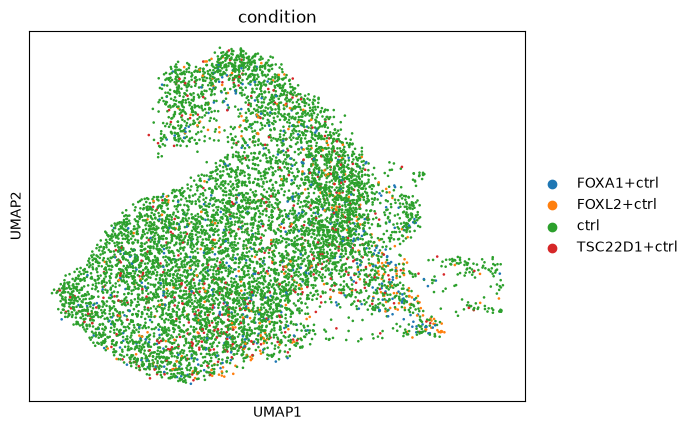

In [16]:
sc.pp.pca(subset, n_comps=30)
sc.pp.neighbors(subset)
sc.tl.umap(subset)

sc.pl.umap(subset, color='condition')

A single expression value = "how much was this one gene being used, in this one cell." 

It's a number, roughly derived from counting how many mRNA copies of that gene's recipe were detected in that cell (then normalized/log-transformed to make cells comparable to each other).

So when you predict "the expression profile" for a perturbation, you're predicting a whole row of numbers like this — one number per gene, saying how active each gene is, on average, in cells that got that perturbation.

**TSC22D1+ctrl →  [Gene_A: 0.5, Gene_B: 3.5, Gene_C: 0.0, ... 5045 values total]**

A list of "how active is each gene" numbers.

**Predicting how a cell's gene expression changes in response to genetic perturbations - including combinations of perturbations that have never been experimentally tested.**

In [18]:
!pip install obonet


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


**Gene Relationship Graphs** - This tasks referes gene relationship graphs to understand/learn epistasis for accurate expression prediction - 
https://academic.oup.com/nar/article/47/D1/D330/5160994


**"Knowledge Graph" - derived from Gene Ontology or co-expression data.**


**Gene-to-Ontology Bipartite Knowledge Graph** - It acts as a structural map of human cell biology by showing exactly which genes are responsible for which functions, processes, or cellular locations.

It is a "Bipartite" Network - 
A bipartite graph means your network contains two entirely different types of nodes that connect to one another:
- Gene Nodes: Individual human genes (e.g., TP53, BRCA1, EGFR).
- GO Term Nodes: Functional biological concepts (e.g., GO:0006915 for apoptosis, GO:0005634 for the cell nucleus).

Edges (lines) only exist between a gene and a GO term. There are no gene-to-gene or GO-to-GO edges in this raw matrix.

An edge between a Gene and a GO ID means: "This gene has been experimentally proven or computationally predicted to play a role in this specific function."

It uses **the graph to calculate functional similarity** - Shared Neighbors = Shared Mechanics: **If Gene A and Gene B are both connected to 15 of the exact same GO terms, they belong to the same cellular pathway.**

In [ ]:
import pandas as pd
import networkx as nx
import requests
import io

url = "https://current.geneontology.org/annotations/gaf/HUMAN-uniprot.gaf.gz"
print("Downloading current human GO annotations (this might take a minute)...")
response = requests.get(url)

if response.status_code == 200:
    df = pd.read_csv(
        io.BytesIO(response.content), 
        sep='\t', 
        comment='!', 
        compression='gzip', 
        header=None, 
        low_memory=False
    )
    
    df_filtered = df[[2, 4]].dropna()
    df_filtered.columns = ['Gene_Symbol', 'GO_ID']
    
    # 4. Build the Network Graph
    G = nx.Graph()
    for _, row in df_filtered.iterrows():
        G.add_edge(row['Gene_Symbol'], row['GO_ID'], edge_type='associated_with')
        
    print(f"Success! Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")


Success! Graph loaded with 56840 nodes and 337820 edges.


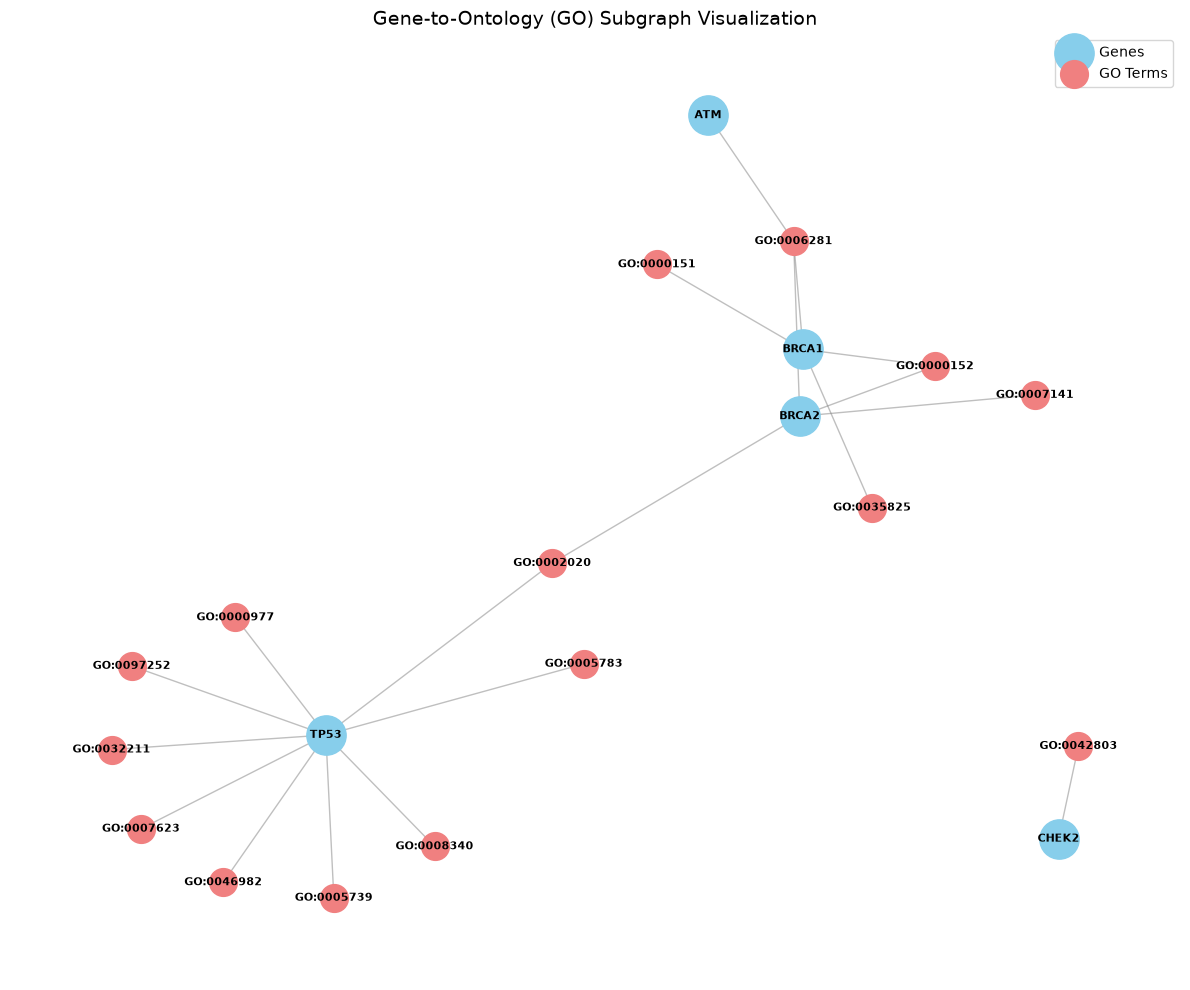

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Filter the graph so for visualisation
# Grabbing a  few specific breast cancer/cell cycle genes 
target_genes = ["TP53", "BRCA1", "BRCA2", "ATM", "CHEK2"]

# Find all GO terms connected to these specific genes
associated_go_terms = set()
for gene in target_genes:
    if gene in G:  # G is the graph you loaded in the previous step
        associated_go_terms.update(G.neighbors(gene))

# Limit the number of GO terms to keep the visual clean (e.g., top 15 terms)
sub_go_terms = list(associated_go_terms)[:15]

# Create a small subgraph containing just our target nodes
subgraph_nodes = target_genes + sub_go_terms
sub_G = G.subgraph(subgraph_nodes)

# 2. Set up the plotting layout
plt.figure(figsize=(12, 10))

# Separate nodes by type so we can color-code them
genes_in_sub = [n for n in sub_G.nodes() if n in target_genes]
go_in_sub = [n for n in sub_G.nodes() if n not in target_genes]


pos = nx.spring_layout(sub_G, k=0.5, seed=42)
nx.draw_networkx_nodes(sub_G, pos, nodelist=genes_in_sub, node_color="skyblue", node_size=800, label="Genes")
nx.draw_networkx_nodes(sub_G, pos, nodelist=go_in_sub, node_color="lightcoral", node_size=400, label="GO Terms")
nx.draw_networkx_edges(sub_G, pos, alpha=0.5, edge_color="gray")
nx.draw_networkx_labels(sub_G, pos, font_size=8, font_weight="bold")
plt.title("Gene-to-Ontology (GO) Subgraph Visualization", fontsize=14)
plt.legend(scatterpoints=1)
plt.axis("off")
plt.tight_layout()
plt.show()
